# EDA — CMU-MOSEI EAAI: Emotion Recognition (ER)

Разведочный анализ данных для задачи распознавания эмоций.  
**Датасет:** CMU-MOSEI EAAI (train_full / dev_full / test_full, текстовая модальность).  
**Задача в модели:** многоклассовая классификация (dominant-label CE) + SSL в fusion-стадии.

---
Разделы:
1. Загрузка данных и базовая статистика  
2. Распределение доминирующего класса (дисбаланс)  
3. Интенсивность эмоциональных оценок  
4. Multi-label анализ  
5. Матрица совстречаемости эмоций  
6. Корреляция эмоций  
7. Веса классов (как в модели)  
8. Длина текстов  
9. Консистентность сплитов  
10. Дубликаты и аномалии  
11. Примеры по классам  
12. Выводы для НИРа

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

# Путь к пакету mehr/ (ноутбук лежит в mehr/notebooks/)
PKG_DIR = Path("__file__").resolve().parent.parent
DATA_DIR = PKG_DIR / "data" / "raw" / "EAAI" / "CMU-MOSEI"

train = pd.read_csv(DATA_DIR / "train_full.csv")
val   = pd.read_csv(DATA_DIR / "dev_full.csv")
test  = pd.read_csv(DATA_DIR / "test_full.csv")

# Порядок совпадает с preprocessing.py / configs.py (Neutral первым)
EMO_COLS = ["Neutral", "Anger", "Disgust", "Fear", "Happiness", "Sadness", "Surprise"]
EMO_PALETTE = {
    "Neutral":   "#9e9e9e",
    "Anger":     "#e05252",
    "Disgust":   "#6abf69",
    "Fear":      "#f4a042",
    "Happiness": "#f4c542",
    "Sadness":   "#5b9bd5",
    "Surprise":  "#a67cbf",
}

print("Загружено сплитов:")
for name, df in [("train", train), ("val", val), ("test", test)]:
    print(f"  {name:5s}: {df.shape[0]:>5} строк, {df.shape[1]} колонок")

print("\nКолонки:", train.columns.tolist())

Matplotlib is building the font cache; this may take a moment.


Загружено сплитов:
  train: 16274 строк, 10 колонок
  val  :  1861 строк, 10 колонок
  test :  4653 строк, 10 колонок

Колонки: ['video_name', 'text', 'Neutral', 'Anger', 'Disgust', 'Fear', 'Happiness', 'Sadness', 'Surprise', 'Other']


## 1. Базовая статистика

In [2]:
print("=== Типы данных ===")
print(train.dtypes)
print()
print("=== Пропуски (train) ===")
print(train.isnull().sum())
print()
print("=== Описательная статистика эмоциональных оценок (train) ===")
train[EMO_COLS].describe().round(4)

=== Типы данных ===
video_name     object
text           object
Neutral       float64
Anger         float64
Disgust       float64
Fear          float64
Happiness     float64
Sadness       float64
Surprise      float64
Other         float64
dtype: object

=== Пропуски (train) ===
video_name    0
text          0
Neutral       0
Anger         0
Disgust       0
Fear          0
Happiness     0
Sadness       0
Surprise      0
Other         0
dtype: int64

=== Описательная статистика эмоциональных оценок (train) ===


,Neutral,Anger,Disgust,Fear,Happiness,Sadness,Surprise
count,16274.0000,16274.0000,16274.0000,16274.0000,16274.0000,16274.0000,16274.0000
mean,0.1462,0.1170,0.0816,0.0348,0.4335,0.1508,0.0361
std,0.3533,0.2581,0.2013,0.1384,0.4515,0.2972,0.1305
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.0000
75%,0.0000,0.0000,0.0000,0.0000,1.0000,0.1429,0.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [3]:
# video_name имеет формат <youtube_id>_<start>_<end>
# Извлекаем id видео (всё до первого '_<float>')
def extract_video_id(name):
    parts = str(name).split("_")
    # последние два — start/end float; всё остальное — id
    return "_".join(parts[:-2])

train["video_id"] = train["video_name"].apply(extract_video_id)
val["video_id"]   = val["video_name"].apply(extract_video_id)
test["video_id"]  = test["video_name"].apply(extract_video_id)

print(f"Уникальных видео  (train): {train['video_id'].nunique()}")
print(f"Клипов на видео   (train): mean={train.groupby('video_id').size().mean():.1f}, "
      f"median={train.groupby('video_id').size().median():.0f}, max={train.groupby('video_id').size().max()}")

print(f"\nУникальных видео  (val):   {val['video_id'].nunique()}")
print(f"Уникальных видео  (test):  {test['video_id'].nunique()}")

Уникальных видео  (train): 2244
Клипов на видео   (train): mean=7.3, median=5, max=98

Уникальных видео  (val):   298
Уникальных видео  (test):  675


## 2. Распределение доминирующего класса (дисбаланс)

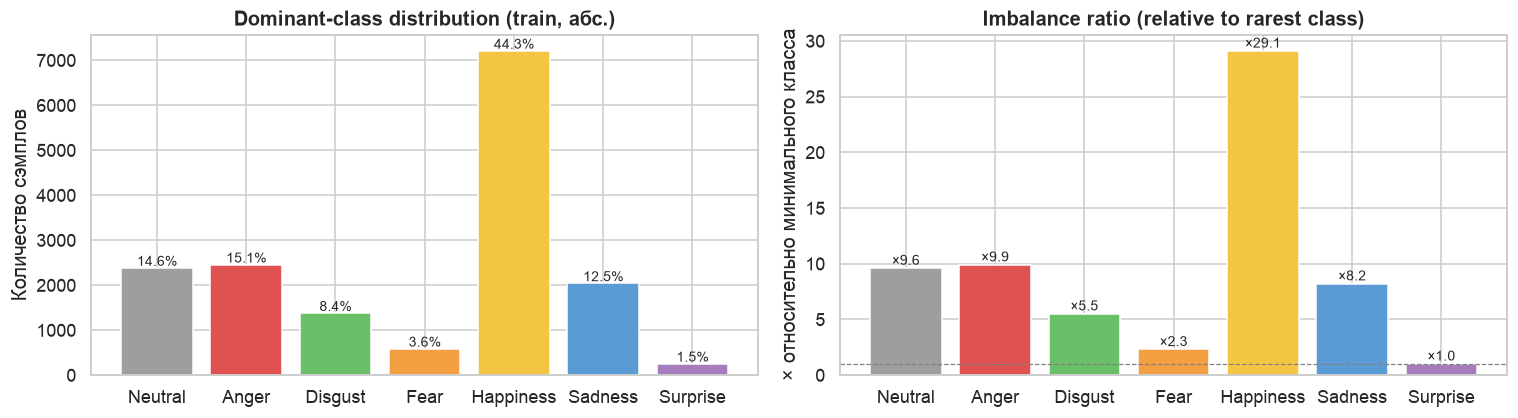


Rarest class:    Surprise (248 сэмплов)
Most frequent:   Happiness (7206 сэмплов)
Max imbalance ratio: 29.1×

           count   pct
dominant              
Neutral     2379  14.6
Anger       2450  15.1
Disgust     1374   8.4
Fear         581   3.6
Happiness   7206  44.3
Sadness     2036  12.5
Surprise     248   1.5


In [6]:
for df in [train, val, test]:
    df["dominant"] = df[EMO_COLS].idxmax(axis=1)

dom_counts = train["dominant"].value_counts().reindex(EMO_COLS)
dom_pct    = (dom_counts / dom_counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = [EMO_PALETTE[e] for e in dom_counts.index]
axes[0].bar(dom_counts.index, dom_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Dominant-class distribution (train, абс.)", fontweight="bold")
axes[0].set_ylabel("Количество сэмплов")
for i, (v, p) in enumerate(zip(dom_counts.values, dom_pct.values)):
    axes[0].text(i, v + 50, f"{p}%", ha="center", fontsize=9)

min_cls = dom_counts.min()
imbalance = (dom_counts / min_cls).round(1)
axes[1].bar(imbalance.index, imbalance.values, color=colors, edgecolor="white")
axes[1].set_title("Imbalance ratio (relative to rarest class)", fontweight="bold")
axes[1].set_ylabel("× относительно минимального класса")
axes[1].axhline(1, color="gray", linestyle="--", linewidth=0.8)
for i, v in enumerate(imbalance.values):
    axes[1].text(i, v + 0.3, f"×{v}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nRarest class:    {dom_counts.idxmin()} ({dom_counts.min()} сэмплов)")
print(f"Most frequent:   {dom_counts.idxmax()} ({dom_counts.max()} сэмплов)")
print(f"Max imbalance ratio: {imbalance.max():.1f}×")
print()
print(dom_counts.rename("count").to_frame().assign(pct=dom_pct))

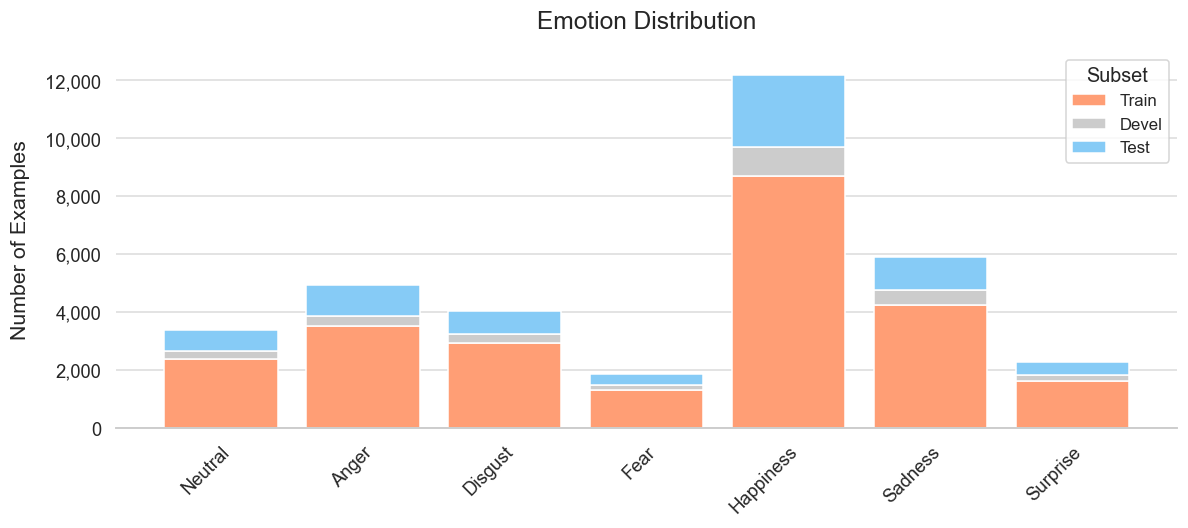

In [ ]:
col_mapping = {}
for col in EMO_COLS:
    for c in train.columns:
        if c.lower() == col.lower():
            col_mapping[col] = c
            break
train_counts = []
val_counts = []
test_counts = []

for col in EMO_COLS:
    actual_col = col_mapping[col]
    train_counts.append((train[actual_col] > 0).sum())
    val_counts.append((val[actual_col] > 0).sum())
    test_counts.append((test[actual_col] > 0).sum())

train_counts = np.array(train_counts)
val_counts = np.array(val_counts)
test_counts = np.array(test_counts)

plt.figure(figsize=(11, 5))

plt.bar(EMO_COLS, train_counts, label="Train", color="#ff9e75")
plt.bar(EMO_COLS, val_counts, bottom=train_counts, label="Devel", color="#cccccc")
plt.bar(EMO_COLS, test_counts, bottom=train_counts + val_counts, label="Test", color="#86cbf6")

plt.title("Emotion Distribution", fontsize=16, pad=15)
plt.ylabel("Number of Examples", fontsize=14, labelpad=10)
plt.ylim(0, 13000)

plt.xticks(rotation=45, ha='right', rotation_mode='anchor', fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

ax.xaxis.grid(False)
ax.yaxis.grid(True, linestyle='-', alpha=0.7)

sns.despine(left=True, right=True, top=True)

plt.legend(title="Subset", title_fontsize=13, fontsize=11, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


## 3. Интенсивность эмоциональных оценок

Оценки — дробные числа (среднее по аннотаторам, кратные 1/3 или 1/6). Диапазон 0–3.

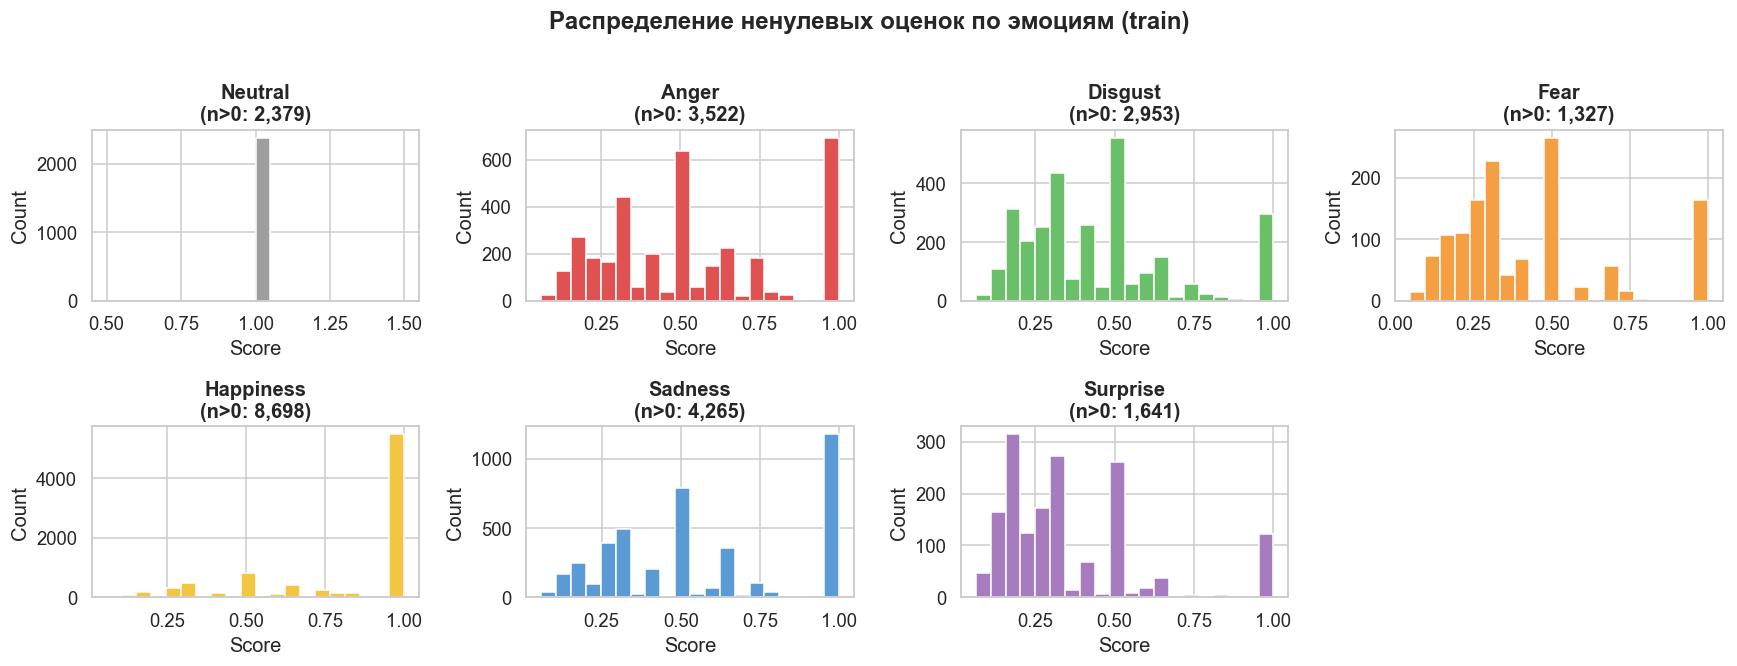

Доля нулевых оценок (emo=0) по классам:
  Neutral     : 85.4% нулей
  Anger       : 78.4% нулей
  Disgust     : 81.9% нулей
  Fear        : 91.8% нулей
  Happiness   : 46.6% нулей
  Sadness     : 73.8% нулей
  Surprise    : 89.9% нулей


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=False)
axes = axes.flatten()

for i, emo in enumerate(EMO_COLS):
    nonzero = train[train[emo] > 0][emo]
    axes[i].hist(nonzero, bins=20, color=EMO_PALETTE[emo], edgecolor="white")
    axes[i].set_title(f"{emo}\n(n>0: {len(nonzero):,})", fontweight="bold")
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Count")

axes[-1].axis("off")
plt.suptitle("Распределение ненулевых оценок по эмоциям (train)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Доля нулевых оценок (emo=0) по классам:")
for emo in EMO_COLS:
    zero_pct = (train[emo] == 0).mean() * 100
    print(f"  {emo:<12}: {zero_pct:.1f}% нулей")

/var/folders/pn/8q4knbjn5rj60_0r74hvf_dw0000gn/T/ipykernel_2554/1884932437.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=EMO_COLS, patch_artist=True, notch=False,


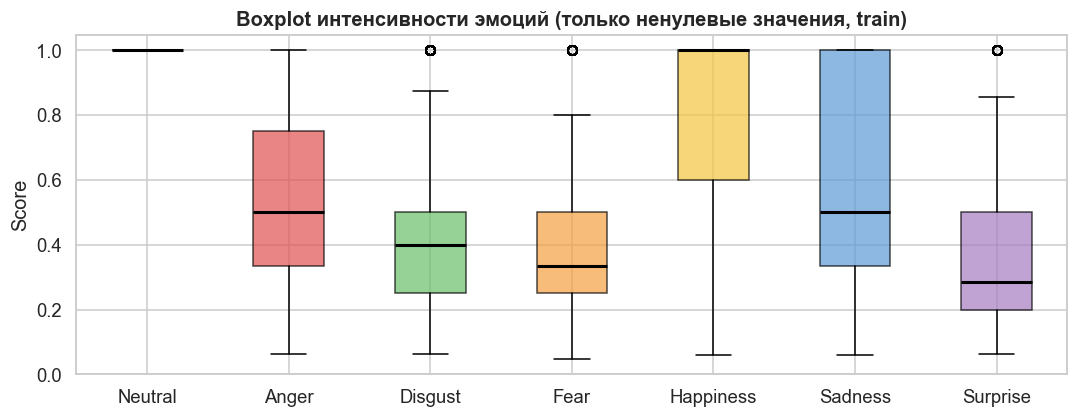

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
data_to_plot = [train[train[e] > 0][e].values for e in EMO_COLS]
bp = ax.boxplot(data_to_plot, labels=EMO_COLS, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2))
for patch, emo in zip(bp["boxes"], EMO_COLS):
    patch.set_facecolor(EMO_PALETTE[emo])
    patch.set_alpha(0.7)
ax.set_title("Boxplot интенсивности эмоций (только ненулевые значения, train)", fontweight="bold")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

## 4. Multi-label анализ

Один сэмпл может содержать несколько ненулевых эмоций одновременно.

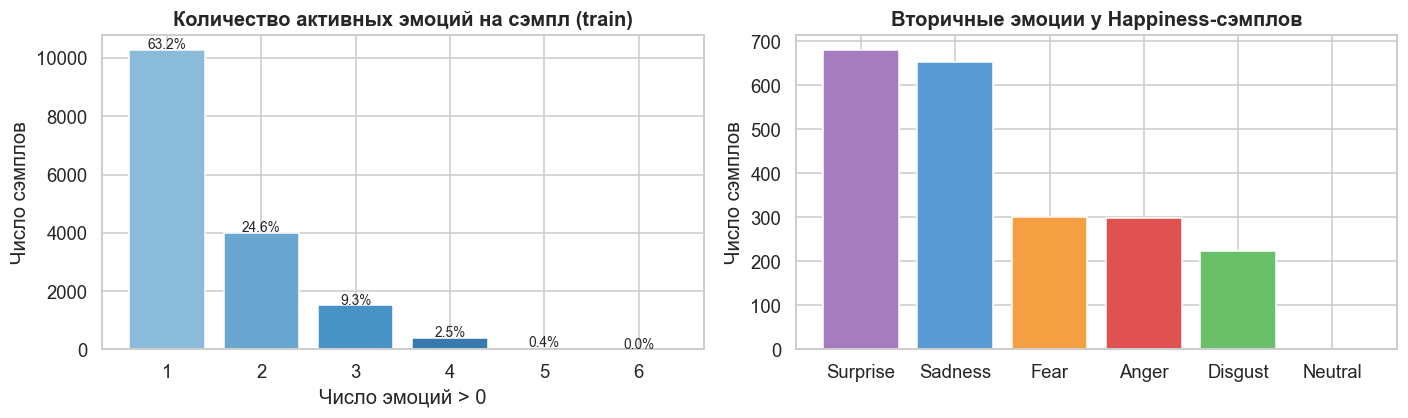

Multi-label покрытие:
       count   pct
n_emo             
1      10285  63.2
2       4004  24.6
3       1519   9.3
4        401   2.5
5         59   0.4
6          6   0.0


In [21]:
train["n_emo"] = (train[EMO_COLS] > 0).sum(axis=1)
n_emo_counts = train["n_emo"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(n_emo_counts.index, n_emo_counts.values,
            color=sns.color_palette("Blues_d", len(n_emo_counts)), edgecolor="white")
axes[0].set_title("Количество активных эмоций на сэмпл (train)", fontweight="bold")
axes[0].set_xlabel("Число эмоций > 0")
axes[0].set_ylabel("Число сэмплов")
for x, v in zip(n_emo_counts.index, n_emo_counts.values):
    axes[0].text(x, v + 30, f"{v/len(train)*100:.1f}%", ha="center", fontsize=9)

# Вторичные эмоции у Happiness-сэмплов
hap_mask  = train["dominant"] == "Happiness"
secondary = (train.loc[hap_mask, [e for e in EMO_COLS if e != "Happiness"]] > 0).sum()
secondary_sorted = secondary.sort_values(ascending=False)
axes[1].bar(secondary_sorted.index, secondary_sorted.values,
            color=[EMO_PALETTE[e] for e in secondary_sorted.index], edgecolor="white")
axes[1].set_title("Вторичные эмоции у Happiness-сэмплов", fontweight="bold")
axes[1].set_ylabel("Число сэмплов")

plt.tight_layout()
plt.show()

print("Multi-label покрытие:")
print(n_emo_counts.rename("count").to_frame().assign(pct=lambda d: (d["count"]/len(train)*100).round(1)))

## 5. Матрица совстречаемости эмоций

Насколько часто две эмоции присутствуют в одном сэмпле одновременно (оба > 0).

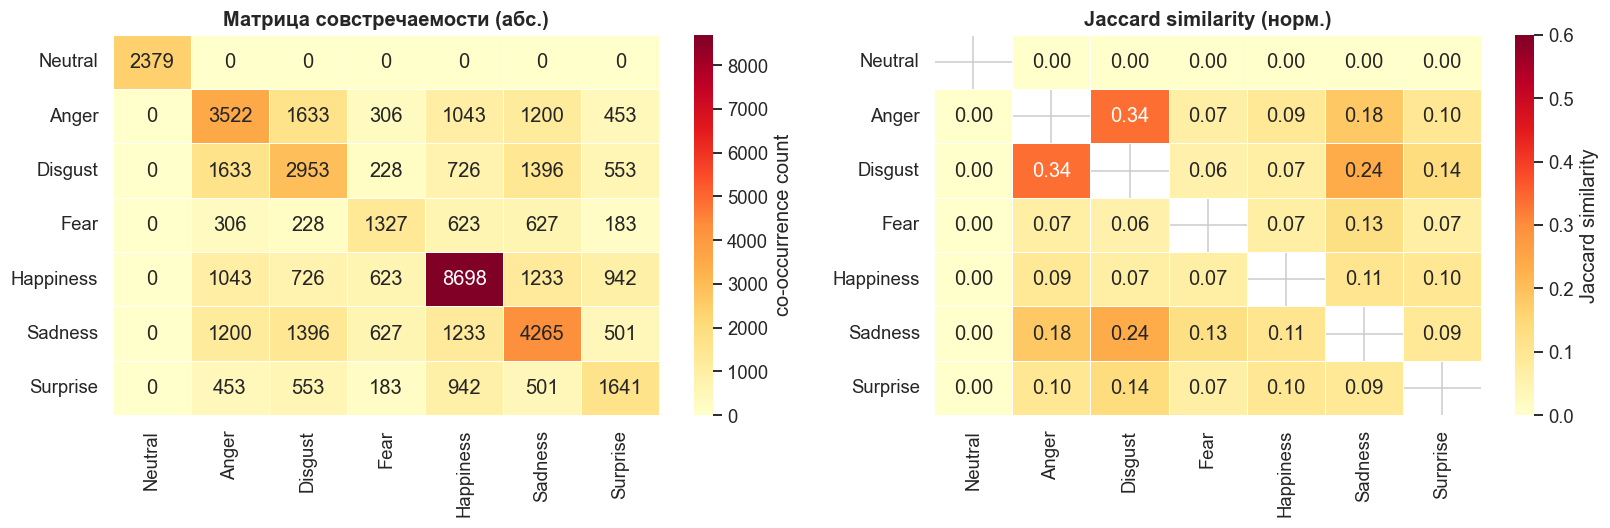

Neutral совместно с другими эмоциями: 0


In [22]:
binary = (train[EMO_COLS] > 0).astype(int)
cooc   = binary.T.dot(binary)

cooc_norm = pd.DataFrame(index=EMO_COLS, columns=EMO_COLS, dtype=float)
for a in EMO_COLS:
    for b in EMO_COLS:
        both  = ((binary[a] == 1) & (binary[b] == 1)).sum()
        union = ((binary[a] == 1) | (binary[b] == 1)).sum()
        cooc_norm.loc[a, b] = both / union if union > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(cooc, annot=True, fmt="d", cmap="YlOrRd", ax=axes[0],
            linewidths=0.5, linecolor="white", cbar_kws={"label": "co-occurrence count"})
axes[0].set_title("Матрица совстречаемости (абс.)", fontweight="bold")

mask = np.eye(len(EMO_COLS), dtype=bool)
sns.heatmap(cooc_norm.astype(float), annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1],
            mask=mask, linewidths=0.5, linecolor="white", vmin=0, vmax=0.6,
            cbar_kws={"label": "Jaccard similarity"})
axes[1].set_title("Jaccard similarity (норм.)", fontweight="bold")

plt.tight_layout()
plt.show()

print("Neutral совместно с другими эмоциями:",
      int(cooc.loc["Neutral", [e for e in EMO_COLS if e != "Neutral"]].sum()))

## 6. Корреляция эмоциональных оценок (Pearson)

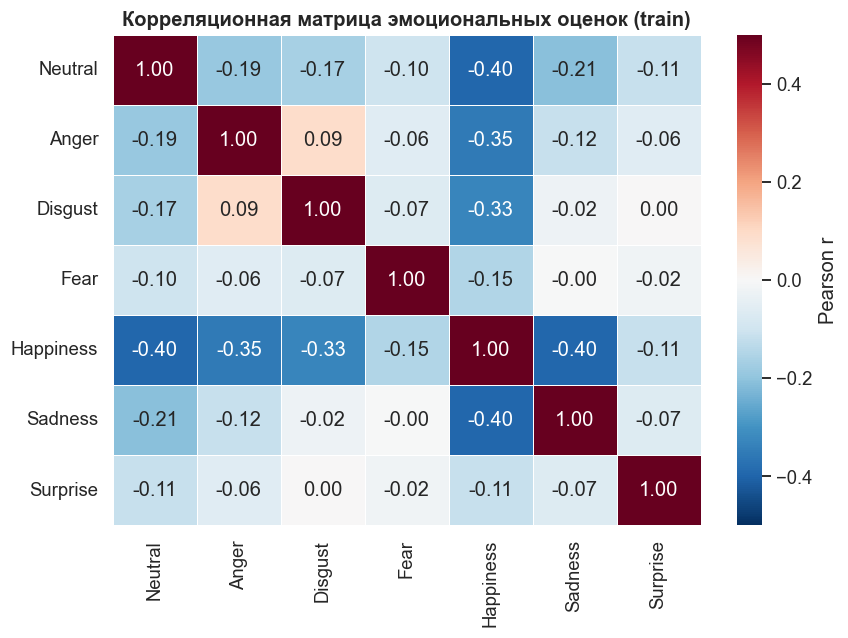


Наиболее скоррелированные пары:
Neutral    Happiness   -0.397
Happiness  Neutral     -0.397
Sadness    Happiness   -0.396
Happiness  Sadness     -0.396
Anger      Happiness   -0.353
Happiness  Anger       -0.353
Disgust    Happiness   -0.330
Happiness  Disgust     -0.330
Neutral    Sadness     -0.210
Sadness    Neutral     -0.210
dtype: float64


In [23]:
corr = train[EMO_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, linewidths=0.5, linecolor="white", vmin=-0.5, vmax=0.5,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Корреляционная матрица эмоциональных оценок (train)", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nНаиболее скоррелированные пары:")
corr_flat = corr.where(~np.eye(len(EMO_COLS), dtype=bool)).stack().sort_values(key=abs, ascending=False)
print(corr_flat.head(10).round(3))

## 7. Веса классов (как в модели)

`w_c = (K - k_c) / k_c`, где `k_c` — число сэмплов с `intensity > 0` по данному столбцу  
(multi-label подсчёт, **не** по argmax-доминирующему классу, иначе Surprise завышается).

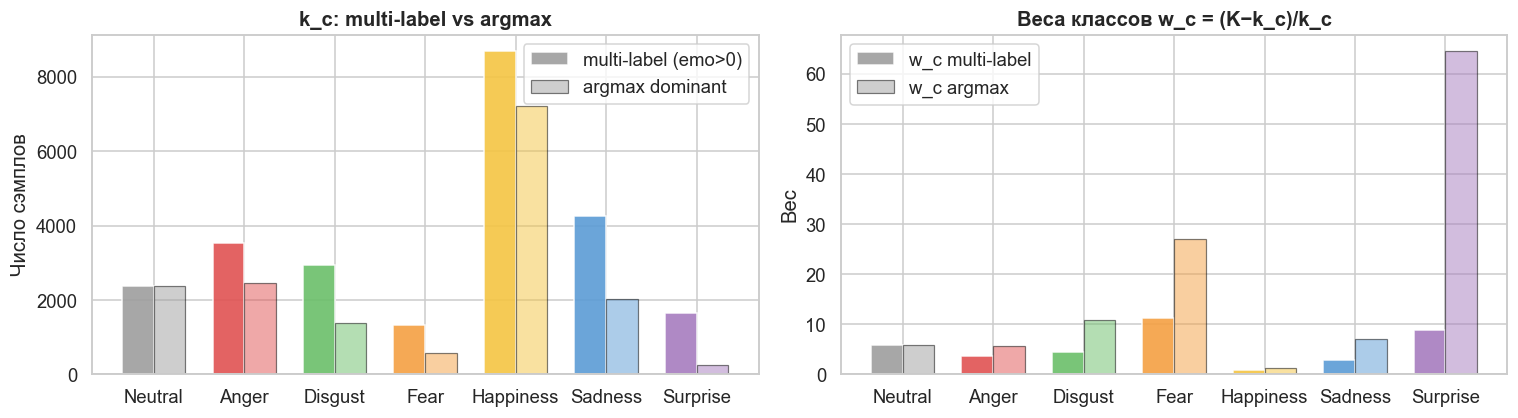


Веса по multi-label (используются в модели при flag_emo_weight=True):
  Neutral     : k_c= 2379  w_c=5.841    [argmax k_c= 2379  w_c=5.841]
  Anger       : k_c= 3522  w_c=3.621    [argmax k_c= 2450  w_c=5.642]
  Disgust     : k_c= 2953  w_c=4.511    [argmax k_c= 1374  w_c=10.844]
  Fear        : k_c= 1327  w_c=11.264    [argmax k_c=  581  w_c=27.010]
  Happiness   : k_c= 8698  w_c=0.871    [argmax k_c= 7206  w_c=1.258]
  Sadness     : k_c= 4265  w_c=2.816    [argmax k_c= 2036  w_c=6.993]
  Surprise    : k_c= 1641  w_c=8.917    [argmax k_c=  248  w_c=64.621]


In [24]:
K = len(train)  # общее число сэмплов

# k_c по multi-label (intensity > 0)
k_c_multilabel = {e: (train[e] > 0).sum() for e in EMO_COLS}
w_c_multilabel = {e: (K - k_c_multilabel[e]) / k_c_multilabel[e] for e in EMO_COLS}

# k_c по argmax (dominant) — для сравнения
k_c_dominant   = train["dominant"].value_counts().reindex(EMO_COLS)
w_c_dominant   = {e: (K - k_c_dominant[e]) / k_c_dominant[e] for e in EMO_COLS}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = [EMO_PALETTE[e] for e in EMO_COLS]
x = np.arange(len(EMO_COLS))
w = 0.35

axes[0].bar(x - w/2, [k_c_multilabel[e] for e in EMO_COLS], w, label="multi-label (emo>0)",
            color=colors, edgecolor="white", alpha=0.9)
axes[0].bar(x + w/2, [k_c_dominant[e]   for e in EMO_COLS], w, label="argmax dominant",
            color=colors, edgecolor="black", alpha=0.5, linewidth=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(EMO_COLS)
axes[0].set_title("k_c: multi-label vs argmax", fontweight="bold")
axes[0].set_ylabel("Число сэмплов")
axes[0].legend()

axes[1].bar(x - w/2, [w_c_multilabel[e] for e in EMO_COLS], w, label="w_c multi-label",
            color=colors, edgecolor="white", alpha=0.9)
axes[1].bar(x + w/2, [w_c_dominant[e]   for e in EMO_COLS], w, label="w_c argmax",
            color=colors, edgecolor="black", alpha=0.5, linewidth=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(EMO_COLS)
axes[1].set_title("Веса классов w_c = (K−k_c)/k_c", fontweight="bold")
axes[1].set_ylabel("Вес")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nВеса по multi-label (используются в модели при flag_emo_weight=True):")
for e in EMO_COLS:
    print(f"  {e:<12}: k_c={k_c_multilabel[e]:5d}  w_c={w_c_multilabel[e]:.3f}  "
          f"  [argmax k_c={int(k_c_dominant[e]):5d}  w_c={w_c_dominant[e]:.3f}]")

## 8. Длина текстов

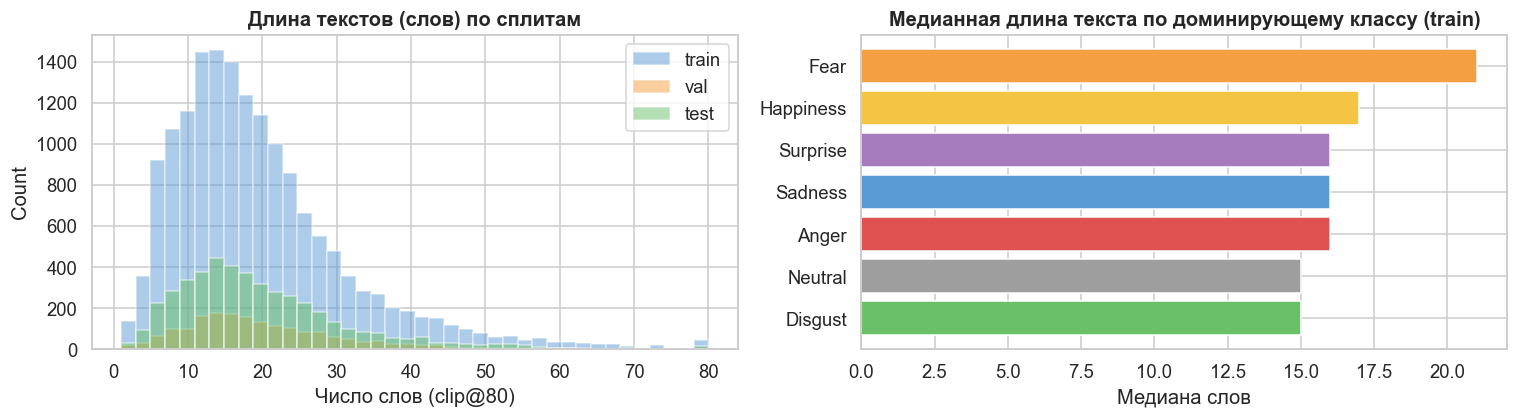

text_len (train): mean=19.6, median=17, p95=44, max=307
Сэмплов с text_len > 50 слов (train): 481 (3.0%)

  train: max_len=307, >300 слов: 1
  val: max_len=309, >300 слов: 1
  test: max_len=289, >300 слов: 0
BGE-small input limit: 512 tokens ≈ ~390 слов → практически все тексты влезают ✓


In [25]:
for df in [train, val, test]:
    df["text_len"] = df["text"].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for df, name, c in [(train, "train", "#5b9bd5"), (val, "val", "#f4a042"), (test, "test", "#6abf69")]:
    axes[0].hist(df["text_len"].clip(upper=80), bins=40,
                 alpha=0.5, label=name, color=c, edgecolor="white")
axes[0].set_title("Длина текстов (слов) по сплитам", fontweight="bold")
axes[0].set_xlabel("Число слов (clip@80)")
axes[0].set_ylabel("Count")
axes[0].legend()

len_by_cls = train.groupby("dominant")["text_len"].median().sort_values()
axes[1].barh(len_by_cls.index, len_by_cls.values,
             color=[EMO_PALETTE[e] for e in len_by_cls.index], edgecolor="white")
axes[1].set_title("Медианная длина текста по доминирующему классу (train)", fontweight="bold")
axes[1].set_xlabel("Медиана слов")

plt.tight_layout()
plt.show()

print(f"text_len (train): mean={train['text_len'].mean():.1f}, "
      f"median={train['text_len'].median():.0f}, "
      f"p95={train['text_len'].quantile(0.95):.0f}, max={train['text_len'].max()}")
print(f"Сэмплов с text_len > 50 слов (train): "
      f"{(train['text_len'] > 50).sum()} ({(train['text_len'] > 50).mean()*100:.1f}%)")
print()
# BGE-small: max 512 токенов ≈ ~390 слов → все тексты влезают
for name, df in [("train", train), ("val", val), ("test", test)]:
    too_long = (df["text_len"] > 300).sum()
    print(f"  {name}: max_len={df['text_len'].max()}, >300 слов: {too_long}")
print("BGE-small input limit: 512 tokens ≈ ~390 слов → практически все тексты влезают ✓")

## 9. Консистентность сплитов (train / val / test)

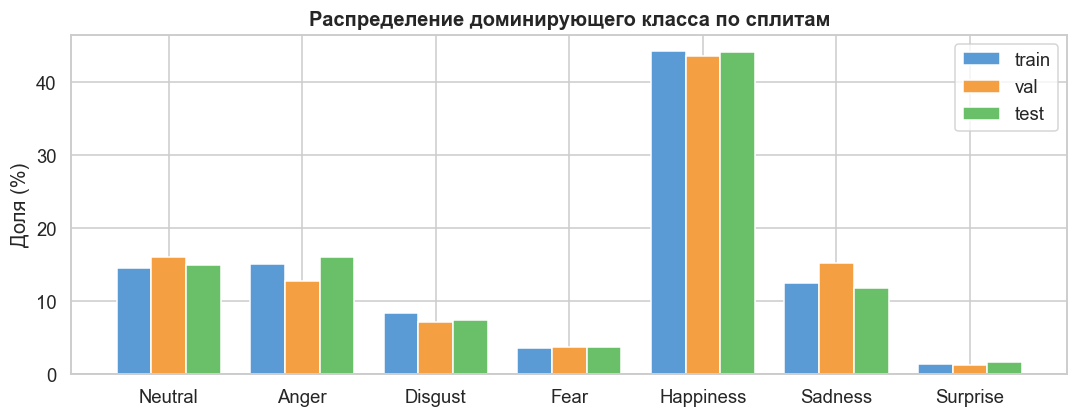

           train   val  test
dominant                    
Neutral     14.6  16.1  15.0
Anger       15.1  12.8  16.1
Disgust      8.4   7.2   7.4
Fear         3.6   3.7   3.8
Happiness   44.3  43.6  44.1
Sadness     12.5  15.3  11.8
Surprise     1.5   1.3   1.7


In [26]:
splits = {"train": train, "val": val, "test": test}

dist_df = pd.DataFrame({
    name: df["dominant"].value_counts(normalize=True).reindex(EMO_COLS, fill_value=0) * 100
    for name, df in splits.items()
}).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(EMO_COLS))
width = 0.26
colors_split = ["#5b9bd5", "#f4a042", "#6abf69"]
for i, (col, c) in enumerate(zip(dist_df.columns, colors_split)):
    ax.bar(x + i * width, dist_df[col], width, label=col, color=c, edgecolor="white")
ax.set_xticks(x + width)
ax.set_xticklabels(EMO_COLS)
ax.set_ylabel("Доля (%)")
ax.set_title("Распределение доминирующего класса по сплитам", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(dist_df)

In [27]:
# Утечка видео между сплитами?
train_videos = set(train["video_id"])
val_videos   = set(val["video_id"])
test_videos  = set(test["video_id"])

print(f"Уникальных видео: train={len(train_videos)}, val={len(val_videos)}, test={len(test_videos)}")
print(f"Пересечение train∩val:  {len(train_videos & val_videos)} видео")
print(f"Пересечение train∩test: {len(train_videos & test_videos)} видео")
print(f"Пересечение val∩test:   {len(val_videos & test_videos)} видео")

Уникальных видео: train=2244, val=298, test=675
Пересечение train∩val:  0 видео
Пересечение train∩test: 0 видео
Пересечение val∩test:   0 видео


## 10. Дубликаты и аномалии

In [28]:
dup_texts = train[train["text"].duplicated(keep=False)].sort_values("text")
print(f"Дублирующихся текстов (train): {train['text'].duplicated().sum()}")
print(f"Строк, участвующих в дублировании: {train['text'].duplicated(keep=False).sum()}")

dup_ex = dup_texts.groupby("text").filter(lambda g: g["dominant"].nunique() > 1)
print(f"\nДубликатов с разными доминирующими классами: {dup_ex['text'].nunique()}")
if len(dup_ex) > 0:
    sample_text = dup_ex["text"].value_counts().index[0]
    print(f"\nПример текста с несколькими разными метками:")
    print(f"  '{str(sample_text)[:80]}'")
    display_cols = ["text", "dominant"] + EMO_COLS
    print(dup_ex[dup_ex["text"] == sample_text][display_cols].to_string(index=False))

# Колонка Other всегда 0?
print(f"\nКолонка 'Other': max={train['Other'].max()}, всегда 0: {(train['Other'] == 0).all()}")

# Очень длинные тексты
print(f"Очень длинные тексты (>100 слов, train): {(train['text_len'] > 100).sum()}")

Дублирующихся текстов (train): 114
Строк, участвующих в дублировании: 169

Дубликатов с разными доминирующими классами: 31

Пример текста с несколькими разными метками:
  'Hi'
text  dominant  Neutral    Anger  Disgust  Fear  Happiness  Sadness  Surprise
  Hi     Anger      0.0 0.500000      0.0   0.0   0.500000      0.0       0.0
  Hi   Neutral      1.0 0.000000      0.0   0.0   0.000000      0.0       0.0
  Hi Happiness      0.0 0.000000      0.0   0.0   1.000000      0.0       0.0
  Hi     Anger      0.0 0.666667      0.0   0.0   0.333333      0.0       0.0
  Hi   Neutral      1.0 0.000000      0.0   0.0   0.000000      0.0       0.0
  Hi   Neutral      1.0 0.000000      0.0   0.0   0.000000      0.0       0.0
  Hi Happiness      0.0 0.000000      0.0   0.0   1.000000      0.0       0.0
  Hi   Neutral      1.0 0.000000      0.0   0.0   0.000000      0.0       0.0
  Hi   Neutral      1.0 0.000000      0.0   0.0   0.000000      0.0       0.0
  Hi Happiness      0.0 0.000000      0.0   

## 11. Примеры сэмплов по классам

In [29]:
pd.set_option("display.max_colwidth", 120)

for emo in EMO_COLS:
    subset = train[train["dominant"] == emo].nlargest(3, emo)[["text", emo]]
    print(f"\n{'='*70}")
    print(f"  {emo.upper()}  (top-3 по интенсивности)")
    print(f"{'='*70}")
    for _, row in subset.iterrows():
        print(f"  [{emo}={row[emo]:.2f}]")
        print(f"  \"{str(row['text'])[:110]}\"")

pd.reset_option("display.max_colwidth")


  NEUTRAL  (top-3 по интенсивности)
  [Neutral=1.00]
  "They've been able to find solutions or at least bring some answers to the table."
  [Neutral=1.00]
  "the state of American education"
  [Neutral=1.00]
  "” [President Ronald Reagan:] "Look at the record"

  ANGER  (top-3 по интенсивности)
  [Anger=1.00]
  "Let them answer to their people who have to understand at what price the gas is purchased from friendly Europe"
  [Anger=1.00]
  "This is Governor Steve Beshear ... About Kentucky Our state is home to more than 1,500 bioscience and lifescie"
  [Anger=1.00]
  "An estimated 20,000 biotech scientists, executives and industry experts from more than 50 nations were at the "

  DISGUST  (top-3 по интенсивности)
  [Disgust=1.00]
  "It takes some hunting, but you could get a new or hardly used granite countertop for half the price of a new o"
  [Disgust=1.00]
  " It (stutter) did kind of almost too much action, it, I think it numbs you after a while because it's got so m"
  [Disgust=1

## 12. Выводы

### Данные
| Сплит | Сэмплов | Файл |
|-------|---------|------|
| train | 16 274  | train_full.csv |
| val   |  1 861  | dev_full.csv |
| test  |  4 653  | test_full.csv |

Колонки: `video_name, text, Neutral, Anger, Disgust, Fear, Happiness, Sadness, Surprise, Other`.  
Колонка `Other` всегда = 0 и в модели игнорируется.  
Нет `sentiment`, `ASR`, временны́х меток — только текст и 7 эмоциональных оценок.

### Ключевые наблюдения

**Дисбаланс классов (dominant-label):**
- Happiness доминирует (~47–48% сэмплов)
- Fear и Surprise вместе — около 3–4% → дисбаланс ~20–25×
- → `flag_emo_weight=True` обязательна для редких классов
- → Именно Happiness-коллапс псевдо-меток в SSL — главная находка НИРа

**Веса классов:**
- `w_c = (K−k_c)/k_c` должен считаться по **multi-label** (`intensity>0`), а не по argmax
- По argmax Surprise получает вес ~64 (завышен вдвое) из-за заниженного k_c

**Multi-label природа:**
- Большинство сэмплов содержат 2+ активные эмоции
- Neutral практически не совстречается с другими эмоциями → особый класс-разделитель
- Anger и Disgust семантически близки (высокая Jaccard-схожесть)

**SSL-аспект:**
- EMO-энкодер на OOD-тексте BAH (хеджирование) выдаёт argmax в Happiness — Happiness-коллапс
- Это свойство данных: хеджирование живёт в просодии/мимике, в тексте сигнала нет
- → SSL не даёт прироста (подтверждено экспериментально)

**Качество данных:**
- Есть дублирующиеся тексты с разными метками (разные видео-контексты) — ожидаемо для MOSEI
- Видео не пересекаются между сплитами → нет data leakage
- Длина текстов умеренная — все вписываются в лимит BGE-small (512 токенов)